In [6]:
import numpy as np 
import pickle 
import pandas as pd 
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
from pathlib import Path
import re 
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    format_model_str as format_model_str_utils,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
    strip_cochdnn9,
    get_x_labels,
    set_bar_labels
)


## Set figure out dir 

fig_out_dir = Path("../CCN_2026_figs")
fig_out_dir.mkdir(parents=True, exist_ok=True)

# import aud_dnn.analyze.plot_utils_AUD as plot_utils_AUD

In [7]:
fmri_eval_dir = Path("/mnt/home/jfeather/ceph/projects/auditory_brain_dnn_for_audio_ssl/results")

res_path = "/mnt/home/jfeather/ceph/projects/auditory_brain_dnn_for_audio_ssl/results/PLOTS_across-models/across-models_barplot_components_NH2015comp_CV-splits-nit-10_median_r2_test_sem_over_it_median_r2_test_performance_sorted.csv"
results_df = pd.read_csv(res_path)
results_df.source_model.unique()

array(['word_kell2018_MatchedDataset_LARS',
       'kell2018_word_speaker_audioset_MatchedDataset_LARS_latest_ckpt',
       'audioset_kell2018_MatchedDataset_LARS_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_1e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_2e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_3e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_4e-01_latest_ckpt',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_latest_ckpt',
       'barlow_word_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment_latest_ckpt',
       'kell2018_dual_barlow_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01',
       'spectemp',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lm

In [8]:
def format_model_str(name):
    """Format model name using figure_utils.format_model_str, which handles all the logic."""
    if name == 'spectemp':
        return name
    if name == 'byol-a':
        return name 
    if "whisper" in name.lower():
        return name
    normalized_name, _, _, _ = format_model_str_utils(name)
    return normalized_name

In [9]:
# format_model_str already returns normalized names, so no need to normalize again
results_df['model_name_str'] = results_df.source_model.map(format_model_str)

In [10]:
# Check unique model names after normalization (for debugging)
results_df['model_name_str'].unique()

array(['CochCNN9 supervised word', 'CochCNN9 supervised multi-task',
       'CochCNN9 supervised audioset', 'CochCNN9 ssl λ=0.0',
       'CochCNN9 ssl λ=0.1', 'CochCNN9 ssl λ=0.2', 'CochCNN9 ssl λ=0.3',
       'CochCNN9 ssl λ=0.4', 'CochCNN9 ssl λ=0.5',
       'CochCNN9 ssl dual λ=0.5', 'spectemp', 'CochCNN9 scaled ssl λ=0.5',
       'CochCNN9 scaled ssl λ=0.0', 'CochCNN9 scaled aud. event'],
      dtype=object)

In [11]:
# Helper function to create x-axis labels


def plot_fmri_components(results_df, exclude_pattern="spectemp|dual|1.0", 
                         n_cols=6, figsize=None, show_spectemp_line=True,
                         ylim_offset=0.05, average_over_components=False,
                         model_order=None):
    """
    Plot bar charts for fMRI component predictions across models.
    
    Parameters
    ----------
    results_df : pd.DataFrame
        DataFrame with columns: 'model_name_str', 'comp', 'median_r2_test', 
        'median_r2_test_std_over_it'
    exclude_pattern : str, optional
        Regex pattern for model names to exclude from bars (default: "spectemp|dual|1.0")
    n_cols : int, optional
        Number of columns in subplot grid (default: 6)
    figsize : tuple, optional
        Figure size as (width, height). If None, auto-calculated based on grid.
    show_spectemp_line : bool, optional
        Whether to show spectrotemporal reference line (default: True)
    ylim_offset : float, optional
        Offset below spectemp line for y-axis lower limit (default: 0.05)
    average_over_components : bool, optional
        If True, plot a single panel showing average across all components (default: False)
    model_order : list, optional
        Custom list of model names to plot and their order. If None, uses standard order
        plus any additional models found in the data.
    
    Returns
    -------
    fig, axes : matplotlib figure and axes (axes is a single Axes if average_over_components=True)
    """
    # Filter data for plotting
    to_plot = results_df[~results_df.model_name_str.str.contains(exclude_pattern)]
    
    # Build model order - use custom if provided, otherwise standard + any extra models in data
    all_models_in_data = to_plot['model_name_str'].unique()
    if model_order is not None:
        # Use custom order, filter to models actually in data
        model_order = [m for m in model_order if m in all_models_in_data]
    else:
        # Start with standard order, filter to models in data
        std_order = get_standard_hue_order()
        model_order = [m for m in std_order if m in all_models_in_data]
        # Add any models in data that aren't in standard order
        extra_models = [m for m in all_models_in_data if m not in model_order]
        model_order = model_order + extra_models
    
    # Build palette
    base_colors = get_standard_base_colors()
    hue_dict = build_model_palette(model_order, base_colors)
    hue_dict['byol-a'] = "k"
    # Add palette for whisper models from Oranges palette
    whisper_models = [m for m in model_order if m.lower().startswith("whisper")]
    if whisper_models:
        whisper_colors = sns.color_palette('Oranges', n_colors=max(len(whisper_models), 2))
        for i, name in enumerate(whisper_models):
            hue_dict[name] = whisper_colors[i % len(whisper_colors)]
    # Get spectrotemporal values for reference line
    spectemp_vals = results_df[results_df.model_name_str.str.contains("spectemp")]

    # Average over components mode - single panel
    if average_over_components:
        if figsize is None:
            figsize = (4, 4)
        
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        
        # Calculate average across components for each model
        avg_data = to_plot.groupby('model_name_str').agg({
            'median_r2_test': 'mean',
            'median_r2_test_std_over_it': 'mean'
        }).reset_index()
        
        # Remove duplicates
        avg_data = avg_data.drop_duplicates(subset=['model_name_str'], keep='first')
        
        # Reorder by model order
        
        # Get the sorted order
        avg_hue_order = avg_data['model_name_str'].values
        
        # Create x positions
        x_pos = np.arange(len(avg_hue_order))
        
        # Get colors for each model
        colors = [hue_dict.get(name, '#444444') for name in avg_hue_order]
        
        # Create barplot
        bar_width = 0.8
        ax.bar(x_pos, avg_data['median_r2_test'].values, width=bar_width, 
               color=colors, edgecolor='black', linewidth=0.5, zorder=0)
        
        # Add error bars
        errors = avg_data['median_r2_test_std_over_it'].values
        ax.errorbar(x_pos, avg_data['median_r2_test'].values, yerr=errors, 
                    fmt='none', color='black', capsize=0, capthick=1, elinewidth=1, zorder=4)
        
        # Add spectrotemporal reference line (average across components)
        if show_spectemp_line and len(spectemp_vals) > 0:
            spectemp_avg = spectemp_vals.groupby('comp')['median_r2_test'].first().mean()
            ax.axhline(spectemp_avg, color='k', linestyle='--', linewidth=1.5, zorder=5, label='spectemp')
            ax.set_ylim(spectemp_avg - ylim_offset, 1)
        
        # Set labels and title
        ax.set_title('Average over components')
        ax.set_ylabel('mean over median $R^2$')
        ax.set_xlabel('')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(get_x_labels(avg_hue_order), rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
        
        # Add legend
        handles, labels = ax.get_legend_handles_labels()
        if any('spectemp' in label for label in labels):
            ax.legend(loc='upper right', frameon=False)
        
        plt.tight_layout()
        return fig, ax
    
    # Per-component mode - multiple subplots
    # Get unique components
    components = to_plot['comp'].unique()
    
    # Create figure with subplots for each component
    n_components = len(components)
    n_rows = (n_components + n_cols - 1) // n_cols
    
    if figsize is None:
        figsize = (20, 3 * n_rows)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_components == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, component in enumerate(components):
        ax = axes[idx]
        
        # Filter data for this component
        comp_data = to_plot[to_plot['comp'] == component].copy()
        
        # Remove duplicates - keep first occurrence of each model_name_str
        comp_data = comp_data.drop_duplicates(subset=['model_name_str'], keep='first')
        
        # Use model order for this component
        comp_data = comp_data.set_index('model_name_str').loc[model_order].reset_index()
        
        # Get the sorted order for this component
        comp_hue_order = comp_data['model_name_str'].values
        
        # Create x positions
        x_pos = np.arange(len(comp_hue_order))
        
        # Get colors for each model
        colors = [hue_dict.get(name, '#444444') for name in comp_hue_order]
        
        # Create barplot with styling matching plot_grouped_bars
        bar_width = 0.8
        bars = ax.bar(x_pos, comp_data['median_r2_test'].values, width=bar_width, 
                      color=colors, edgecolor='black', linewidth=0.5, zorder=0)
        
        # Add error bars (vertical lines) using median_r2_test_std_over_it
        errors = comp_data['median_r2_test_std_over_it'].values
        ax.errorbar(x_pos, comp_data['median_r2_test'].values, yerr=errors, 
                    fmt='none', color='black', capsize=0, capthick=1, elinewidth=1, zorder=4)
        
        # Add spectrotemporal reference line
        if show_spectemp_line and len(spectemp_vals) > 0:
            spectemp_row = spectemp_vals[spectemp_vals.comp == component]
            if len(spectemp_row) > 0:
                spectemp_med = spectemp_row['median_r2_test'].values[0]
                ax.axhline(spectemp_med, color='k', linestyle='--', linewidth=1.5, zorder=5, label='spectemp')
                ax.set_ylim(spectemp_med - ylim_offset, 1)
        
        # Set labels and title
        ax.set_title(f'{component}')
        if idx == 0 or idx == n_cols:
            ax.set_ylabel('median $R^2$')
        ax.set_xlabel('')
        ax.set_xticks(x_pos)
        
        # Create x-axis labels using helper function
        ax.set_xticklabels(get_x_labels(comp_hue_order), rotation=45, ha='right')
        
        ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
    
    # Hide extra subplots if any
    for idx in range(n_components, len(axes)):
        axes[idx].set_visible(False)
    
    # Add legend for spectemp dashed line
    handles, labels = axes[0].get_legend_handles_labels()
    if any('spectemp' in label or 'Spectrotemporal' in label for label in labels):
        axes[0].legend(loc='upper right', frameon=False)
    
    return fig, axes

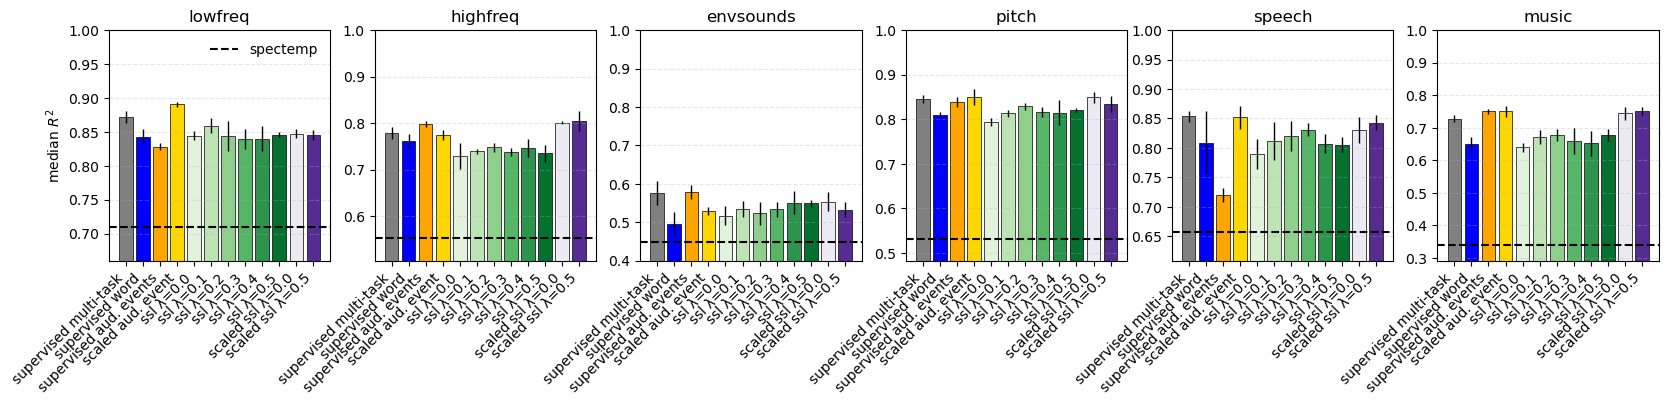

In [12]:
# Example usage with the existing results_df
fig, axes = plot_fmri_components(results_df)

# Plot Score Across Layers for Each Model

Use `plot_score_across_layers` from the analysis scripts to visualize model performance across layers.

In [13]:
# Import plot_utils_AUD functions (without modifying the .py scripts)
import sys, os
import matplotlib.pyplot as plt

# Fix for matplotlib style name change in newer versions
# 'seaborn-pastel' was renamed to 'seaborn-v0_8-pastel' in matplotlib 3.6+
# We patch plt.style.use temporarily to handle the old style names in resources.py
# Only patch if not already patched (to avoid recursion on re-run)
if not hasattr(plt.style.use, '_is_patched'):
    _original_style_use = plt.style.use
    def _patched_style_use(style):
        try:
            _original_style_use(style)
        except OSError:
            if 'seaborn' in str(style):
                try:
                    # Try the new naming convention
                    _original_style_use(style.replace('seaborn-', 'seaborn-v0_8-'))
                except OSError:
                    pass  # Skip if style not available
            else:
                raise
    _patched_style_use._is_patched = True
    plt.style.use = _patched_style_use

# Add paths for auditory_brain_dnn modules (using jfeather's copies)
sys.path.append('/mnt/home/jfeather/ceph/projects/auditory_brain_dnn_for_audio_ssl/aud_dnn')
sys.path.append('/mnt/home/jfeather/ceph/projects/auditory_brain_dnn_for_audio_ssl/aud_dnn/analyze')

from plot_utils_AUD import (
    plot_score_across_layers,
    concat_dfs_modelwise,
    get_subject_pivot
    # RESULTDIR_ROOT,
    # SAVEDIR_CENTRALIZED,
)
from resources import (
    AUDIO_SSL_MODEL_LIST_2,
    d_layer_reindex,
    d_layer_names,
    d_model_names,
    d_comp_names,
    d_roi_colors,
)

# Restore original style.use after imports
plt.style.use = _original_style_use

print("Imports successful!")

RESULTDIR_ROOT = "/mnt/home/jfeather/ceph/projects/auditory_brain_dnn_for_audio_ssl/results"

ROOT: /mnt/ceph/users/jfeather/projects/auditory_brain_dnn_for_audio_ssl
Imports successful!


In [14]:
AUDIO_SSL_MODEL_LIST_COCHDNN9_FIG = [
 'kell2018_word_speaker_audioset_MatchedDataset_LARS_latest_ckpt',
'word_kell2018_MatchedDataset_LARS',
 'audioset_kell2018_MatchedDataset_LARS_latest_ckpt',
 'kell2018_audioset_unbalanced_supervised',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_1e-01_latest_ckpt',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_2e-01_latest_ckpt',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_3e-01_latest_ckpt',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_4e-01_latest_ckpt',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_latest_ckpt',
 'kell2018_dual_barlow_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only',
 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only',
 'spectemp',
 ]

In [15]:
# Configuration for plot_score_across_layers
target = 'NH2015comp'  # Components target

# Use the model list from resources, or define custom list
source_models = AUDIO_SSL_MODEL_LIST_COCHDNN9_FIG

# Paths - using the results directory from plot_utils_AUD
mapping = 'AUD-MAPPING-Ridge'

print(f"Target: {target}")
print(f"Number of models: {len(source_models)}")
print(f"Models: {source_models}")

Target: NH2015comp
Number of models: 14
Models: ['kell2018_word_speaker_audioset_MatchedDataset_LARS_latest_ckpt', 'word_kell2018_MatchedDataset_LARS', 'audioset_kell2018_MatchedDataset_LARS_latest_ckpt', 'kell2018_audioset_unbalanced_supervised', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_1e-01_latest_ckpt', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_2e-01_latest_ckpt', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_3e-01_latest_ckpt', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_4e-01_latest_ckpt', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_latest_ckpt', 'kell2018_dual_barlow_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only', 'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only', 'spectemp']


In [16]:
# Build a combined dataframe with score, model, layer, component for all models
# Load from pre-computed across-layers CSV files (yerr is empty for components - only 1 "subject")
import os

all_results = []

for source_model in source_models:
    # Skip spectemp and models not in layer dictionary
    if source_model == 'spectemp':
        continue
    if source_model not in d_layer_reindex:
        print(f"Skipping {source_model} - not in d_layer_reindex")
        continue
    
    try:
        # Get layers for this model
        layers = d_layer_reindex[source_model]
        outputs_dir = Path(RESULTDIR_ROOT) / source_model / 'outputs'
        
        # Loop through each component  
        for comp in ['lowfreq', 'highfreq', 'envsounds', 'pitch', 'speech', 'music']:
            comp_name = d_comp_names[comp]
            
            # Load the across-layers CSV for this component
            csv_path = outputs_dir / f'across-layers_comp-{comp}_{source_model}_NH2015comp_median_r2_test.csv'
            
            if csv_path.exists():
                df_comp = pd.read_csv(csv_path, index_col=0)
                
                # Get scores from the 'none' row (the actual scores, not yerr)
                if 'none' in df_comp.index:
                    scores = df_comp.loc['none']
                    
                    for i, layer in enumerate(layers):
                        if layer in scores.index:
                            all_results.append({
                                'model': source_model,
                                'layer': layer,
                                'layer_idx': i,
                                'component': comp_name,
                                'comp_key': comp,
                                'score': scores[layer]
                            })
            else:
                print(f"CSV not found: {csv_path}")
        
        print(f"Processed: {source_model}")
        
    except Exception as e:
        print(f"Error processing {source_model}: {e}")
        import traceback
        traceback.print_exc()

# Create combined dataframe
df_all = pd.DataFrame(all_results)
print(f"\nCombined dataframe shape: {df_all.shape}")
print(f"Models: {df_all['model'].nunique()}")
print(f"Components: {df_all['component'].unique()}")
df_all.head(20)

Processed: kell2018_word_speaker_audioset_MatchedDataset_LARS_latest_ckpt


Processed: word_kell2018_MatchedDataset_LARS
Processed: audioset_kell2018_MatchedDataset_LARS_latest_ckpt
Processed: kell2018_audioset_unbalanced_supervised
Processed: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01
Processed: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_1e-01_latest_ckpt
Processed: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_2e-01_latest_ckpt
Processed: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_3e-01_latest_ckpt
Processed: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_4e-01_latest_ckpt
Processed: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_latest_ckpt
Processed: kell2018_dual_barlow_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01
Processed: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only
Processed: kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only

Combined dataframe shape: (702, 6)
Models: 13
Components: ['Low frequency' 'High frequency' 'Env. sound'

,model,layer,layer_idx,component,comp_key,score
0,kell2018_word_speaker_audioset_MatchedDataset_...,relu0,0,Low frequency,lowfreq,0.648453
1,kell2018_word_speaker_audioset_MatchedDataset_...,maxpool0,1,Low frequency,lowfreq,0.790997
2,kell2018_word_speaker_audioset_MatchedDataset_...,relu1,2,Low frequency,lowfreq,0.838413
3,kell2018_word_speaker_audioset_MatchedDataset_...,maxpool1,3,Low frequency,lowfreq,0.839947
4,kell2018_word_speaker_audioset_MatchedDataset_...,relu2,4,Low frequency,lowfreq,0.868817
5,kell2018_word_speaker_audioset_MatchedDataset_...,relu3,5,Low frequency,lowfreq,0.850215
6,kell2018_word_speaker_audioset_MatchedDataset_...,relu4,6,Low frequency,lowfreq,0.827009
7,kell2018_word_speaker_audioset_MatchedDataset_...,avgpool,7,Low frequency,lowfreq,0.842023
8,kell2018_word_speaker_audioset_MatchedDataset_...,relufc,8,Low frequency,lowfreq,0.771073
9,kell2018_word_speaker_audioset_MatchedDataset_...,relu0,0,High frequency,highfreq,0.632593


In [17]:
df_all['model_name_str'] = df_all.model.apply(format_model_str)

df_all

,model,layer,layer_idx,component,comp_key,score,model_name_str
0,kell2018_word_speaker_audioset_MatchedDataset_...,relu0,0,Low frequency,lowfreq,0.648453,CochCNN9 supervised multi-task
1,kell2018_word_speaker_audioset_MatchedDataset_...,maxpool0,1,Low frequency,lowfreq,0.790997,CochCNN9 supervised multi-task
2,kell2018_word_speaker_audioset_MatchedDataset_...,relu1,2,Low frequency,lowfreq,0.838413,CochCNN9 supervised multi-task
3,kell2018_word_speaker_audioset_MatchedDataset_...,maxpool1,3,Low frequency,lowfreq,0.839947,CochCNN9 supervised multi-task
4,kell2018_word_speaker_audioset_MatchedDataset_...,relu2,4,Low frequency,lowfreq,0.868817,CochCNN9 supervised multi-task
...,...,...,...,...,...,...,...
697,kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1...,relu2,4,Music,music,0.728587,CochCNN9 scaled ssl λ=0.5
698,kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1...,relu3,5,Music,music,0.762146,CochCNN9 scaled ssl λ=0.5
699,kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1...,relu4,6,Music,music,0.731051,CochCNN9 scaled ssl λ=0.5
700,kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1...,avgpool,7,Music,music,0.747101,CochCNN9 scaled ssl λ=0.5


# Only up to relu4

In [ ]:
## Per-layer plot

# apply format_model_str to model column
to_plot = df_all.copy()
to_plot = to_plot[~to_plot.model_name_str.str.contains("0.1|0.2|0.3|0.4|1.0|dual", na=False)]
# drop layers after relu4
to_plot = to_plot[~to_plot.layer.str.isin(["avgpool", "relufc"], na=False)]


hue_dict = build_model_palette(to_plot.model_name_str.unique(), get_standard_base_colors())

# Point plot: dots with model hue and black edge lines
# Create figure with extra space for legend in a "4th column"
panel_size = 2.5
title_fontsize = 10 

fig, axes = plt.subplots(2, 3, figsize=(panel_size * 4, panel_size * 2))
axes = axes.flatten()

for i, comp in enumerate(to_plot.component.unique()): 
    g = sns.pointplot(
        data=to_plot[to_plot.component == comp],
        x="layer",
        y="score",
        hue="model_name_str",
        palette=hue_dict,
        ax=axes[i],
        markers="o",
        dodge=True,
        markersize=4,
        linestyle='-',
        linewidth=1,
    )
    # Add black edges to markers
    for line in axes[i].lines:
        line.set_markeredgecolor('black')
        line.set_markeredgewidth(0.5)
        
    axes[i].set_xlabel("")
    if i > 2:
        axes[i].set_xlabel("Layer", fontsize=title_fontsize)
    axes[i].set_ylabel("", fontsize=title_fontsize)
    if i in [0,3]:
        axes[i].set_ylabel("Median $R^2$", fontsize=title_fontsize)

    title = f"Component {i+1}"
    if "Music" in comp:
        title = f"{title} (music)"
    if "Speech" in comp:
        title = f"{title} (speech)"
    axes[i].set_title(title, fontsize=title_fontsize)
    axes[i].legend().remove()
    # set xtick labels 
    axes[i].set_xticks(axes[i].get_xticks())
    x_labels = axes[i].get_xticklabels() 
    
    if i > 2:
        axes[i].set_xticklabels(x_labels, rotation=45, ha='right', fontsize=title_fontsize)
    else:
        axes[i].set_xticklabels([""] * len(x_labels), rotation=45, ha='right', fontsize=title_fontsize)
        
    # set ytick labels
    axes[i].set_yticks(axes[i].get_yticks())
    axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=title_fontsize)
    sns.despine(ax=axes[i])

# Add legend spanning the right side (like a 4th column)
handles, labels = axes[0].get_legend_handles_labels()
labels = [model_label(l, use_ssl_names=True) for l in labels]
leg = fig.legend(
    handles, 
    labels, 
    loc='center right',
    bbox_to_anchor=(0.85, 0.97),
    # title='Model',
    fontsize=10,
    frameon=False,
    ncol=4,
)

# plt.subplots_adjust(wspace=0.5, hspace=0.4)  # Make room for legend on the right
fig.suptitle("Model predictions of fMRI response components", y=1.05, fontsize=title_fontsize);
# fig.tight_layout()

plt.savefig(fig_out_dir / "component_predictions_main_models.pdf", bbox_inches='tight',)# transparent=True)

# ALL layers

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


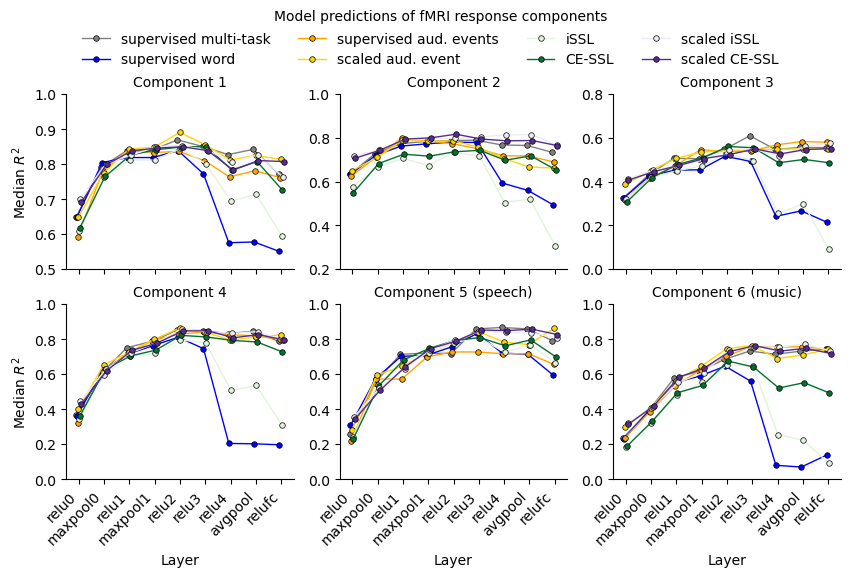

In [18]:
## Per-layer plot

# apply format_model_str to model column
to_plot = df_all.copy()
to_plot = to_plot[~to_plot.model_name_str.str.contains("0.1|0.2|0.3|0.4|1.0|dual", na=False)]

hue_dict = build_model_palette(to_plot.model_name_str.unique(), get_standard_base_colors())

# Point plot: dots with model hue and black edge lines
# Create figure with extra space for legend in a "4th column"
panel_size = 2.5
title_fontsize = 10 

fig, axes = plt.subplots(2, 3, figsize=(panel_size * 4, panel_size * 2))
axes = axes.flatten()

for i, comp in enumerate(to_plot.component.unique()): 
    g = sns.pointplot(
        data=to_plot[to_plot.component == comp],
        x="layer",
        y="score",
        hue="model_name_str",
        palette=hue_dict,
        ax=axes[i],
        markers="o",
        dodge=True,
        markersize=4,
        linestyle='-',
        linewidth=1,
    )
    # Add black edges to markers
    for line in axes[i].lines:
        line.set_markeredgecolor('black')
        line.set_markeredgewidth(0.5)
        
    axes[i].set_xlabel("")
    if i > 2:
        axes[i].set_xlabel("Layer", fontsize=title_fontsize)
    axes[i].set_ylabel("", fontsize=title_fontsize)
    if i in [0,3]:
        axes[i].set_ylabel("Median $R^2$", fontsize=title_fontsize)

    title = f"Component {i+1}"
    if "Music" in comp:
        title = f"{title} (music)"
    if "Speech" in comp:
        title = f"{title} (speech)"
    axes[i].set_title(title, fontsize=title_fontsize)
    axes[i].legend().remove()
    # set xtick labels 
    axes[i].set_xticks(axes[i].get_xticks())
    x_labels = axes[i].get_xticklabels() 
    
    if i > 2:
        axes[i].set_xticklabels(x_labels, rotation=45, ha='right', fontsize=title_fontsize)
    else:
        axes[i].set_xticklabels([""] * len(x_labels), rotation=45, ha='right', fontsize=title_fontsize)
        
    # set ytick labels
    axes[i].set_yticks(axes[i].get_yticks())
    axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=title_fontsize)
    sns.despine(ax=axes[i])

# Add legend spanning the right side (like a 4th column)
handles, labels = axes[0].get_legend_handles_labels()
labels = [model_label(l, use_ssl_names=True) for l in labels]
leg = fig.legend(
    handles, 
    labels, 
    loc='center right',
    bbox_to_anchor=(0.85, 0.97),
    # title='Model',
    fontsize=10,
    frameon=False,
    ncol=4,
)

# plt.subplots_adjust(wspace=0.5, hspace=0.4)  # Make room for legend on the right
fig.suptitle("Model predictions of fMRI response components", y=1.05, fontsize=title_fontsize);
# fig.tight_layout()

plt.savefig(fig_out_dir / "component_predictions_main_models.pdf", bbox_inches='tight',)# transparent=True)

In [ ]:
hue_dict.keys()

In [54]:
labels

['supervised multi-task',
 'supervised word',
 'supervised aud. events',
 'scaled aud. event',
 'iSSL',
 'CE-SSL',
 'scaled iSSL',
 'scaled CE-SSL']

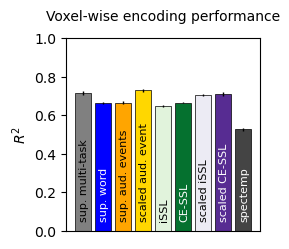

In [67]:
fname = "PLOTS_across-models/across-models_roi-None_NH2015_CV-splits-nit-10_within_subject_sem_median_r2_test_c_performance_sorted_cochdnn9fig.csv"
voxel_df = pd.read_csv(fmri_eval_dir / fname)

# Sort values in descending order by median

for_plot_df = voxel_df[~voxel_df['source_model'].str.contains("dual") & ~voxel_df['source_model'].str.startswith("barlow")]


# models to plot 
models_to_plot = [
    'kell2018_word_speaker_audioset_MatchedDataset_LARS_latest_ckpt',
    'word_kell2018_MatchedDataset_LARS',
    'audioset_kell2018_MatchedDataset_LARS_latest_ckpt',
    'kell2018_audioset_unbalanced_supervised',
    'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01',
    'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_latest_ckpt',
    'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only',
    'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only',
    "spectemp",
    
]

for_plot_df = for_plot_df[for_plot_df['source_model'].isin(models_to_plot)]

# Put models in standard order 
names = [format_model_str(n) for n in for_plot_df.source_model.values]
for_plot_df['model_name_str'] = names
std_order = get_standard_hue_order()
model_order = [m for m in std_order if m in np.unique(names)]
# Add any models in data that aren't in standard order
extra_models = [m for m in names if m not in model_order]
model_order = model_order + extra_models

# sort values for plot 
for_plot_df = for_plot_df.set_index('model_name_str').loc[model_order].reset_index()


# Build hue_dict so each formatted name is mapped correctly
names = for_plot_df.model_name_str.unique()
hue_dict = build_model_palette(names, get_standard_base_colors())
plot_names = get_x_labels(names)
plot_names = [model_label(l, use_ssl_names=True) for l in plot_names]

# Now map color to each bar using the formatted names in "names"
bar_colors = [hue_dict.get(n, '#444444') for n in names]


# bar_width = 
panel_size = 2.5
fig, axs = plt.subplots(figsize=(panel_size,panel_size))
bar_width=0.8
fontsize = 10 

bars = axs.bar(
    for_plot_df['model_name_str'].values,
    for_plot_df['median_r2_test_c_mean'].values,
    color=bar_colors,
    width=bar_width, 
    edgecolor='black',
    linewidth=0.5, 
    
)

med = for_plot_df['median_r2_test_c_mean'].values
axs.errorbar(np.arange(len(med)), 
             med, 
             yerr=for_plot_df['median_r2_test_c_yerr'].values, 
             fmt='none', 
             color='black', 
             capsize=0, 
             capthick=1, 
             elinewidth=1)

# Iterate over the bars and add text
for ix, bar in enumerate(bars):
    height = bar.get_height() 
    if height > 0.5:
        height = 0.05
    else:
        height = bar.get_height() + 0.0225
    

    bar_name = plot_names[ix].replace('supervised', 'sup.')
    text_color = "k"
    if any(sub_str in bar_name for sub_str in ["word", "CE", "spectemp"]):
        text_color = "white"
    axs.text(
        0.05 + (bar.get_x() + bar.get_width() / 2.),  # X-coordinate (center of the bar)
        height,                               # Y-coordinate (top of the bar)
        bar_name,                          # The text to display
        ha='center',                          # Horizontal alignment
        va='bottom',                          # Vertical alignment (places text slightly above)
        rotation=90,
        color=text_color,
        fontsize=fontsize-2,
    )



# axs.set_xticks(np.arange(len(med)))
axs.set_xticks([])
axs.set_xticklabels([], rotation=45, ha='right')

y_min = for_plot_df['median_r2_test_c_mean'].min() * 0.9
y_max = for_plot_df['median_r2_test_c_mean'].max()  * 1.1
axs.set_ylim(y_min, y_max)
axs.set_ylabel('$R^2$', fontsize=fontsize)
axs.set_title('Voxel-wise encoding performance', y=1.05, fontsize=fontsize);
axs.set_ylim(0,1)
axs.tick_params(axis='both', which='major', labelsize=fontsize)


# fig.tight_layout()

# plt.savefig(fig_out_dir / "voxelwise_core_models_w_spectemp.pdf", bbox_inches='tight',)# transparent=True)

In [145]:
names = for_plot_df.model_name_str.unique()
hue_dict = build_model_palette(names, get_standard_base_colors())
plot_names = get_x_labels(names)
# plot_names = [model_label(l, use_ssl_names=True) for l in plot_names]
model_label(plot_names[-2], use_ssl_names=True)

'scaled ssl λ=0.5'

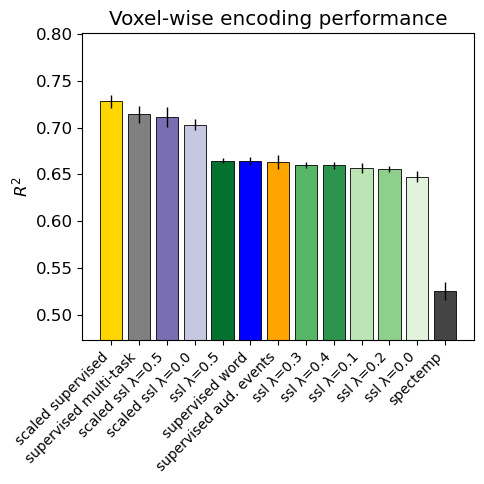

In [152]:
fname = "PLOTS_across-models/across-models_roi-None_NH2015_CV-splits-nit-10_within_subject_sem_median_r2_test_c_performance_sorted_cochdnn9fig.csv"
voxel_df = pd.read_csv(fmri_eval_dir / fname)

# Sort values in descending order by median

for_plot_df = voxel_df[~voxel_df['source_model'].str.contains("dual") & ~voxel_df['source_model'].str.startswith("barlow")]
sort_idx = np.argsort(-for_plot_df['median_r2_test_c_mean'].values)
med = for_plot_df['median_r2_test_c_mean'].values[sort_idx]
error = for_plot_df['median_r2_test_c_yerr'].values[sort_idx]
raw_names = for_plot_df['source_model'].unique()[sort_idx]
names = [format_model_str(n) for n in raw_names]

# Build hue_dict so each formatted name is mapped correctly
hue_dict = build_model_palette(names, get_standard_base_colors())
plot_names = get_x_labels(names)
# Now map color to each bar using the formatted names in "names"
bar_colors = [hue_dict.get(n, '#444444') for n in names]

fig, axs = plt.subplots(figsize=(5,5))
axs.bar(np.arange(len(med)), 
        med, 
        color=bar_colors, 
        linewidth=0.6, 
        edgecolor='black')
axs.errorbar(np.arange(len(med)), 
             med, 
             yerr=error, 
             fmt='none', 
             color='black', 
             capsize=0, 
             capthick=1, 
             elinewidth=1)
axs.set_xticks(np.arange(len(med)))
axs.set_xticklabels(plot_names, rotation=45, ha='right')

y_min = min(med) * 0.9
y_max = max(med) * 1.1
axs.set_ylim(y_min, y_max)
axs.set_ylabel('$R^2$')
axs.set_title('Voxel-wise encoding performance')
fig.tight_layout()


## For supplement 

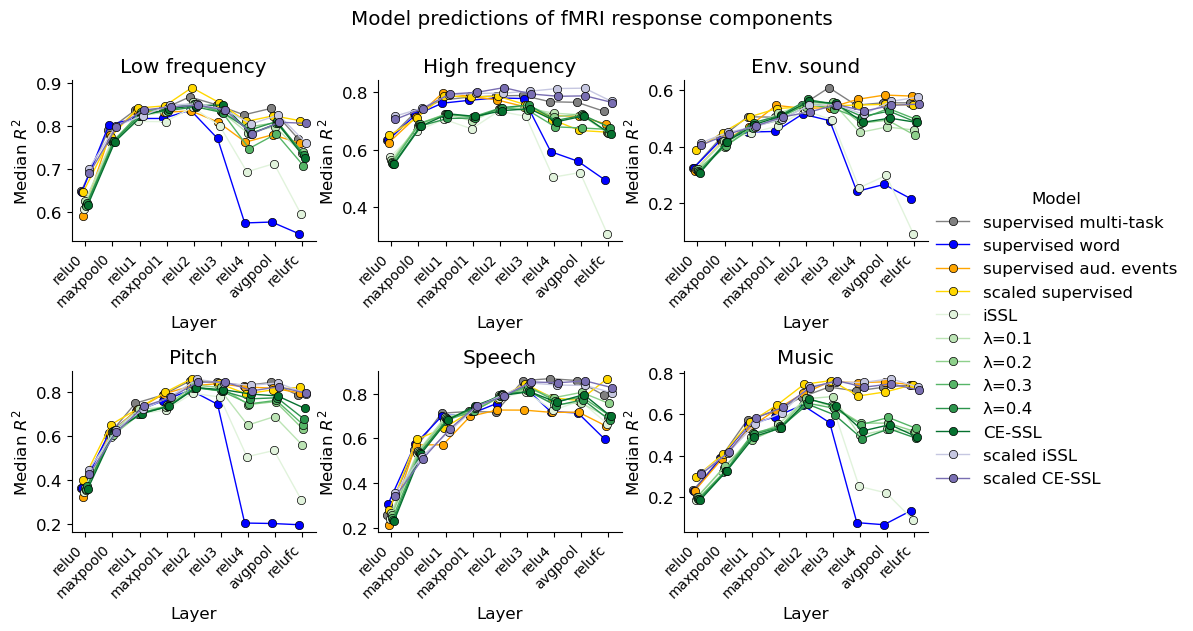

In [129]:
# apply format_model_str to model column
to_plot = df_all.copy()
to_plot['model_name_str'] = to_plot['model'].apply(format_model_str)
to_plot = to_plot[~to_plot.model_name_str.str.contains("dual|1.0")]

hue_dict = build_model_palette(to_plot.model_name_str.unique(), get_standard_base_colors())

# Point plot: dots with model hue and black edge lines
# Create figure with extra space for legend in a "4th column"
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for i, comp in enumerate(to_plot.component.unique()): 
    g = sns.pointplot(
        data=to_plot[to_plot.component == comp],
        x="layer",
        y="score",
        hue="model_name_str",
        palette=hue_dict,
        ax=axes[i],
        markers="o",
        dodge=True,
        markersize=6,
        linestyle='-',
        linewidth=1,
    )
    # Add black edges to markers
    for line in axes[i].lines:
        line.set_markeredgecolor('black')
        line.set_markeredgewidth(0.5)
    
    axes[i].set_xlabel("Layer")
    axes[i].set_ylabel("Median $R^2$")
    axes[i].set_title(comp)
    axes[i].legend().remove()
    axes[i].set_xticks(axes[i].get_xticks())
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    sns.despine(ax=axes[i])

# Add legend spanning the right side (like a 4th column)
handles, labels = axes[0].get_legend_handles_labels()
labels = [model_label(l, use_ssl_names=True) for l in labels]
fig.legend(
    handles, 
    labels, 
    loc='center right',
    bbox_to_anchor=(1.0, 0.5),
    title='Model',
    frameon=False,
)

fig.tight_layout()
fig.subplots_adjust(right=0.78)  # Make room for legend on the right
fig.suptitle("Model predictions of fMRI response components", y=1.05);

In [137]:
source_model

'kell2018_audioset_unbalanced_supervised'

/mnt/home/igriffith/ceph/projects/cochdnn/auditory_brain_dnn/aud_dnn/analyze/plot_utils_AUD.py:485: RuntimeWarning: invalid value encountered in divide
  yerr = np.std(demeaned.values.T + piv.mean().mean(), axis=1) / np.sqrt(


(source_layer     relu0  maxpool0     relu1  maxpool1     relu2     relu3  \
 subj_idx                                                                   
 none          0.281686  0.595235  0.644691  0.719823  0.777659  0.842809   
 
 source_layer     relu4   avgpool    relufc  
 subj_idx                                    
 none          0.781458  0.768596  0.863755  ,
 array([nan, nan, nan, nan, nan, nan, nan, nan, nan]))

source_layer,relu0,maxpool0,relu1,maxpool1,relu2,relu3,relu4,avgpool,relufc
subj_idx,,,,,,,,,
none,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Plot model average over voxels

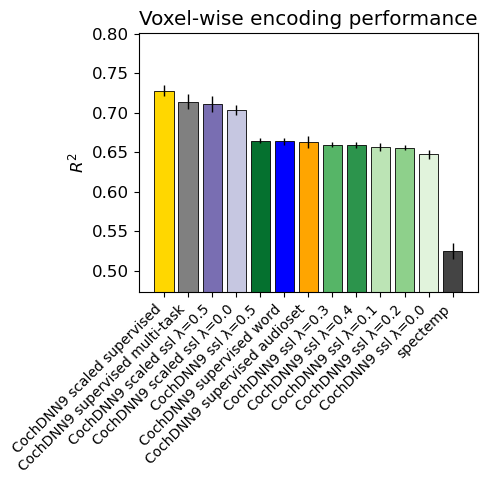

## Plot BYOL-A and Whisper

In [105]:
fmri_eval_dir = Path("/mnt/home/jfeather/ceph/projects/auditory_brain_dnn_for_audio_ssl/results/PLOTS_across-models/")
fname = "across-models_barplot_components_NH2015comp_CV-splits-nit-10_median_r2_test_sem_over_it_median_r2_test_performance_sorted_whisper_models.csv"

whisper_byola_df = pd.read_csv(fmri_eval_dir / fname)

In [140]:
whisper_byola_df['model_name_str'] = whisper_byola_df['source_model'].map(format_model_str)

In [148]:
whisper_byola_df['source_model'].unique()

array(['whisper_tiny.en', 'whisper_medium', 'whisper_large-v3',
       'whisper_large-v3-turbo', 'Kell2018multitask', 'ResNet50multitask',
       'byol-a',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only',
       'kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_5e-01_audioset_only',
       'spectemp'], dtype=object)

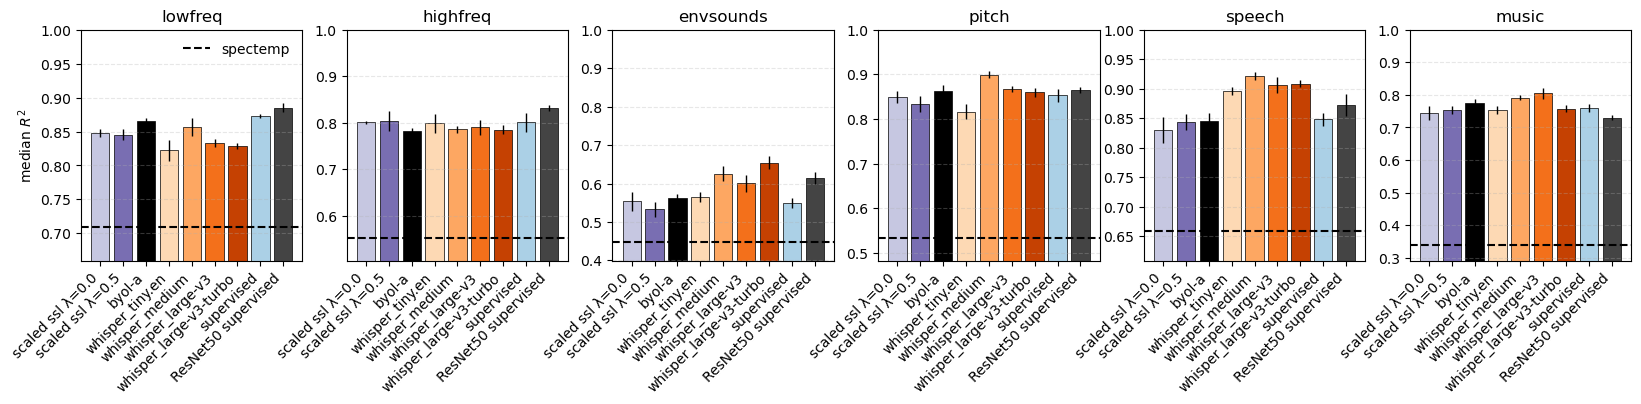

In [147]:
fig, axes = plot_fmri_components(whisper_byola_df)